Methira Binath Kahawita
w2119674



importing all the libraries needed for the Naïve Bayes, Logistic Regression and K-Nearest Neighbours models

In [ ]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import train_test_split to divide dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import StandardScaler to normalize numeric features
from sklearn.preprocessing import StandardScaler

# Import LabelEncoder to convert categorical variables to numeric
from sklearn.preprocessing import LabelEncoder

# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

# Import K Nearest Neighbours classifier
from sklearn.neighbors import KNeighborsClassifier

# Import Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

dropping loan aproval status and id


Loading the cleaned data set

In [ ]:
# Load the cleaned dataset used for classification modelling
data_frame = pd.read_csv("/content/loan_approval_data_cleaned (1).csv")

# Display first rows to verify dataset
data_frame.head()

,id,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,19180,40.0,182004,3,3,1,35000,8.00,0.19,0,11,1,35000
1,28072,40.0,90000,0,3,2,35000,12.42,0.39,0,14,1,35000
2,32074,40.0,131004,0,9,5,30000,7.90,0.23,0,13,1,30000
3,7224,40.0,150000,0,9,0,25000,11.89,0.17,0,11,1,25000
4,14471,40.0,132000,0,3,2,25000,16.82,0.22,0,17,1,25000


Encoding the  categorical variables such as home_ownership,loan_intent,payment_default_on_file These variables should be numeric

In [ ]:
# Create label encoder object
encoder = LabelEncoder()

# Convert home ownership category into numeric values
data_frame['home_ownership'] = encoder.fit_transform(data_frame['home_ownership'])

# Convert loan intent category into numeric values
data_frame['loan_intent'] = encoder.fit_transform(data_frame['loan_intent'])

# Convert payment default flag into numeric values
data_frame['payment_default_on_file'] = encoder.fit_transform(data_frame['payment_default_on_file'])

Define Features and Target

defining the inputs(x) or else features   and define the target variable  as y


In [ ]:
# Define input features (X) by dropping the target and regression column
X = data_frame.drop(['loan_approval_status','max_allowed_loan','id'], axis=1)

# Define target variable (y)
y = data_frame['loan_approval_status']

# Display feature names used for modelling
print(X.columns)

# Show dataset shape
print(X.shape)

Index(['age', 'income', 'home_ownership', 'employment_length', 'loan_intent',
       'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length'],
      dtype='object')
(58635, 10)


In [ ]:
X.columns

Index(['age', 'income', 'home_ownership', 'employment_length', 'loan_intent',
       'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length'],
      dtype='object')

Train/Test Split
Spliting the data set into training set and testing set
80 percent to traing 20 percent to testing
stratify means traind and test sets keep the same ratio
random state =42 ,same radom split every time

In [ ]:
X.shape

(58635, 10)

In [ ]:
# Split the dataset into training and testing subsets
# 80% training and 20% testing
# Stratify ensures class distribution remains the same
# random_state ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Feature Scaling or els einput scaling


In [ ]:
y_train.value_counts()

,count
loan_approval_status,
1,40229
0,6679


In [ ]:
y_test.value_counts()

,count
loan_approval_status,
1,10057
0,1670


In [ ]:
# Create scaler object
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train = scaler.fit_transform(X_train)

# Apply same transformation to testing data
X_test = scaler.transform(X_test)

makiing the logistic regression model
initialisng

In [ ]:
# Build Logistic Regression Model
# Create Logistic Regression model
lr_model = LogisticRegression()

# Train the model on training data
lr_model.fit(X_train, y_train)

# Predict loan approval on test data
lr_pred = lr_model.predict(X_test)

In [ ]:
X.columns

Index(['age', 'income', 'home_ownership', 'employment_length', 'loan_intent',
       'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length'],
      dtype='object')

Building the naive bayes model

In [ ]:
# Create Naive Bayes classifier
nb_model = GaussianNB()

# Train Naive Bayes model
nb_model.fit(X_train, y_train)

# Predict test data
nb_pred = nb_model.predict(X_test)

building the knn model

In [ ]:

# Create KNN model with K = 5 neighbours
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the KNN model
knn_model.fit(X_train, y_train)

# Predict test dataset
knn_pred = knn_model.predict(X_test)

Evaluate Models
first printing the confsuion matrix comparing test and prediction results



[[ 645 1025]
 [ 254 9803]]
              precision    recall  f1-score   support

           0       0.72      0.39      0.50      1670
           1       0.91      0.97      0.94     10057

    accuracy                           0.89     11727
   macro avg       0.81      0.68      0.72     11727
weighted avg       0.88      0.89      0.88     11727

AUC: 0.8729651763391781


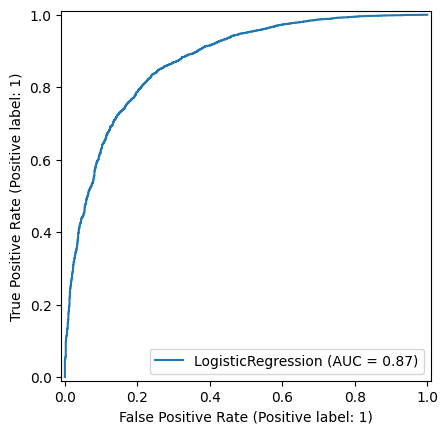

In [ ]:
#------- Logistic regression Evaluation ------

# Print confusion matrix for Logistic Regression
print(confusion_matrix(y_test, lr_pred))

# Print classification report
print(classification_report(y_test, lr_pred))

# Calculate ROC AUC score
print("AUC:", roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]))

# Plot ROC curve
RocCurveDisplay.from_estimator(lr_model, X_test, y_test)

[[1021  649]
 [1063 8994]]
              precision    recall  f1-score   support

           0       0.49      0.61      0.54      1670
           1       0.93      0.89      0.91     10057

    accuracy                           0.85     11727
   macro avg       0.71      0.75      0.73     11727
weighted avg       0.87      0.85      0.86     11727

AUC: 0.8614291353655422


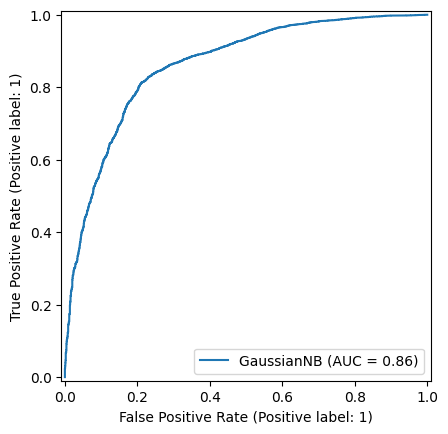

In [ ]:
#-----Naive bayes Evaluation ---------


# Confusion Matrix
print(confusion_matrix(y_test, nb_pred))

# Classification Report
print(classification_report(y_test, nb_pred))

# AUC Score
print("AUC:", roc_auc_score(y_test, nb_model.predict_proba(X_test)[:,1]))

# ROC Curve
RocCurveDisplay.from_estimator(nb_model, X_test, y_test)

[[ 916  754]
 [ 253 9804]]
              precision    recall  f1-score   support

           0       0.78      0.55      0.65      1670
           1       0.93      0.97      0.95     10057

    accuracy                           0.91     11727
   macro avg       0.86      0.76      0.80     11727
weighted avg       0.91      0.91      0.91     11727

AUC: 0.8568207028321799


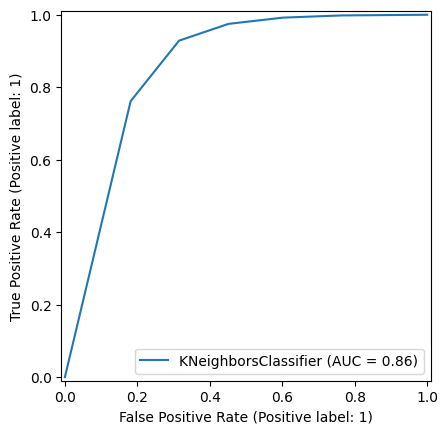

In [ ]:
#------KNN Model evaluation ----------



# Confusion Matrix
print(confusion_matrix(y_test, knn_pred))

# Classification Report
print(classification_report(y_test, knn_pred))

# AUC Score
print("AUC:", roc_auc_score(y_test, knn_model.predict_proba(X_test)[:,1]))

# ROC Curve
RocCurveDisplay.from_estimator(knn_model, X_test, y_test)


evaluating the knn model before applying hyperparameter tuning

first creating the  KNN model with k = 5 neighbors
Then training  the model using training data
then predicts results for test data


In [ ]:
# BEFORE TUNING

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_before = knn.predict(X_test)

print("BEFORE TUNING")
print(confusion_matrix(y_test, y_pred_before))
print(classification_report(y_test, y_pred_before))

BEFORE TUNING
[[ 916  754]
 [ 253 9804]]
              precision    recall  f1-score   support

           0       0.78      0.55      0.65      1670
           1       0.93      0.97      0.95     10057

    accuracy                           0.91     11727
   macro avg       0.86      0.76      0.80     11727
weighted avg       0.91      0.91      0.91     11727



Hyperparameter Tuning (GridSearchCV)

first define different values to test for KNN
creating grid search which here tries all parameter combinations
 and uses 5-fold cross-validation
and also optimizes for recall




In [ ]:
X.columns

Index(['age', 'income', 'home_ownership', 'employment_length', 'loan_intent',
       'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length'],
      dtype='object')

In [ ]:
# Define parameter grid for KNN
param_grid = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform','distance']
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='recall'
)

# Fit grid search to training data
grid_search.fit(X_train, y_train)

# Print best parameters
print(grid_search.best_params_)

{'n_neighbors': 9, 'weights': 'uniform'}


evaluates the optimized KNN model after hyperparameter tuning


In [ ]:


# After tuning

# Get best model from GridSearch
best_knn = grid_search.best_estimator_

# Predict using optimized model
best_pred = best_knn.predict(X_test)

# Evaluate new model
print(confusion_matrix(y_test, best_pred))
print(classification_report(y_test, best_pred))

[[ 882  788]
 [ 206 9851]]
              precision    recall  f1-score   support

           0       0.81      0.53      0.64      1670
           1       0.93      0.98      0.95     10057

    accuracy                           0.92     11727
   macro avg       0.87      0.75      0.80     11727
weighted avg       0.91      0.92      0.91     11727

